In [4]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

with h5py.File("alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

import scipy.spatial

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

import sys
import os

module_path = os.path.abspath(os.path.join("../../src/"))
if module_path not in sys.path:
    sys.path.append(module_path)

from HubbardTweezer.Hubbard.lattice import sqr_lattice

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array([4, 4]))
xlinks = abs(links[:, 0] - links[:, 1]) == 1
ylinks = np.logical_not(xlinks)
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

Vi = dat["t_ij"].diagonal(axis1=1, axis2=2)

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

3001
1190


# Analysis

## Single trap depth

Text(0, 0.5, 'V')

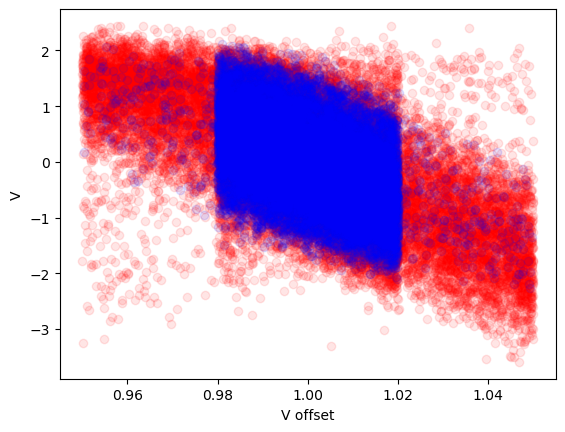

In [7]:
plt.scatter(
    dat["V_offset"][~mask].flatten(),
    Vi[~mask].flatten(),
    color="r",
    alpha=0.1,
)
plt.scatter(
    dat["V_offset"][mask].flatten(),
    Vi[mask].flatten(),
    color="b",
    alpha=0.1,
)
plt.xlabel("V offset")
plt.ylabel("V")

## Positions

### No. of neighbours

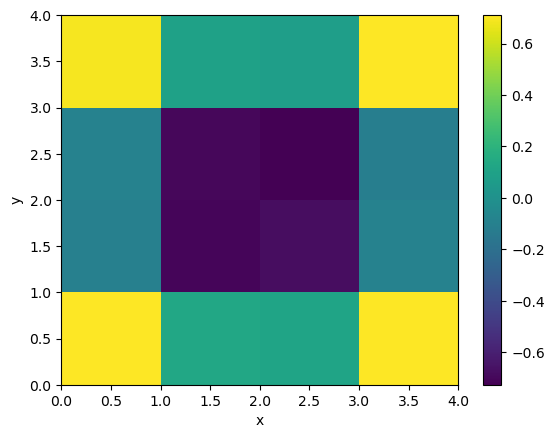

In [8]:
avgV = np.mean(Vi[mask], axis=0)
plt.pcolormesh(avgV.reshape(4, 4))
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()

In [7]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn

nno = nneighbor(width, height)

In [26]:
avgV = np.mean(Vi[mask], axis=0)

Text(0, 0.5, 'U_i')

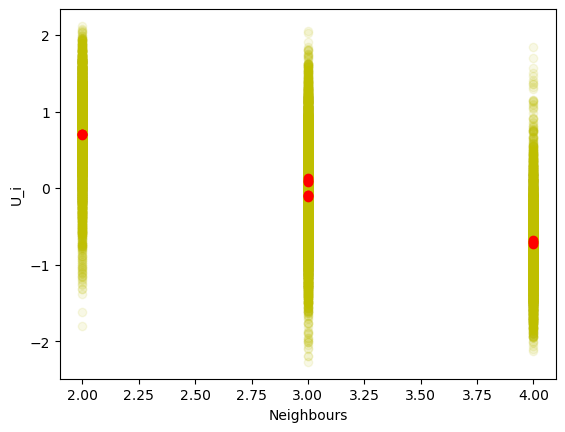

In [28]:
sidx = list(range(16))
plt.scatter(
    np.tile(nno, nmask), Vi[mask][:, sidx].flatten(), color="y", alpha=0.1
)
plt.scatter(nno, avgV[sidx].flatten(), color="r", alpha=1)
plt.xlabel("Neighbours")
plt.ylabel("U_i")

There is a dependence of V_i on trap neighbor number.

Study the correlation of V_offset dependence on the number of neighbours.

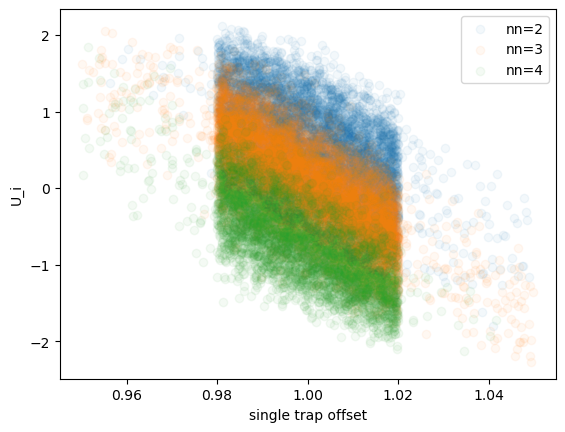

In [3]:
for i in [2, 3, 4]:
    plt.scatter(
        dat["V_offset"][mask][:, nno == i],
        Vi[mask][:, nno == i].flatten(),
        alpha=5e-2,
        label=f"nn={i}",
    )
plt.xlabel("single trap depth")
plt.ylabel("U_i")
plt.legend()

The V_offset slope has no clear dependence on the neighboring number.

### Avg. trap spacing

In [5]:
from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr


avgr = avg_trap_spacing(np.arange(width * height)).T

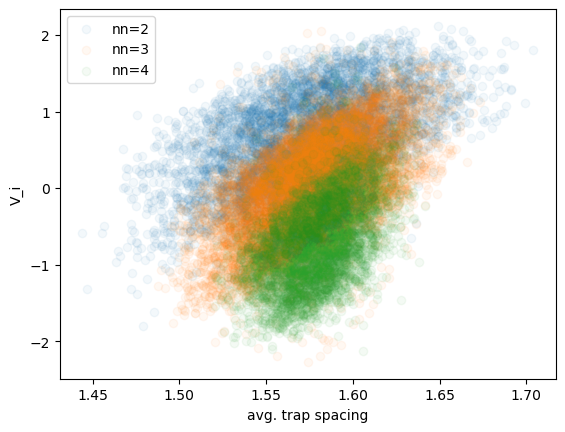

In [8]:
for i in [2, 3, 4]:
    plt.scatter(
        avgr[:, nno == i], Vi[mask][:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}"
    )
plt.xlabel("avg. trap spacing")
plt.ylabel("V_i")
plt.legend()

The dependence seems to be more complex. Less clear dependence on trap spacing.

In [31]:
from typing import Iterable


def tot_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([tot_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    totr = np.sum(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return totr


totr = tot_trap_spacing(np.arange(16)).T

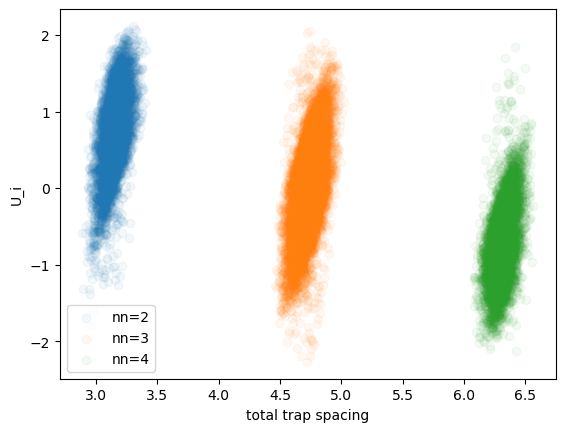

In [32]:
for i in [2, 3, 4]:
    plt.scatter(totr[:, nno == i], Vi[mask][:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}")
plt.xlabel("total trap spacing")
plt.ylabel("U_i")
plt.legend()

In [9]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


from typing import Iterable


def avg_trap_spacing(links, idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(links, i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr


nno = nneighbor(width, height)
avgrx = avg_trap_spacing(links[xlinks], np.arange(width * height)).T
avgry = avg_trap_spacing(links[ylinks], np.arange(width * height)).T

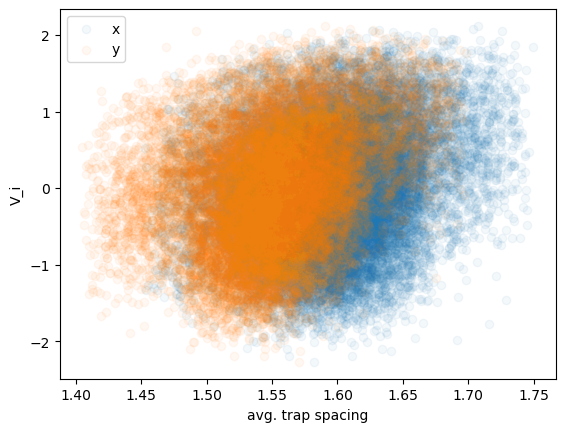

In [12]:
plt.scatter(avgrx, Vi[mask].flatten(), alpha=5e-2, label=f"x")
plt.scatter(avgry, Vi[mask].flatten(), alpha=5e-2, label=f"y")
plt.xlabel("avg. trap spacing")
plt.ylabel("V_i")
plt.legend()

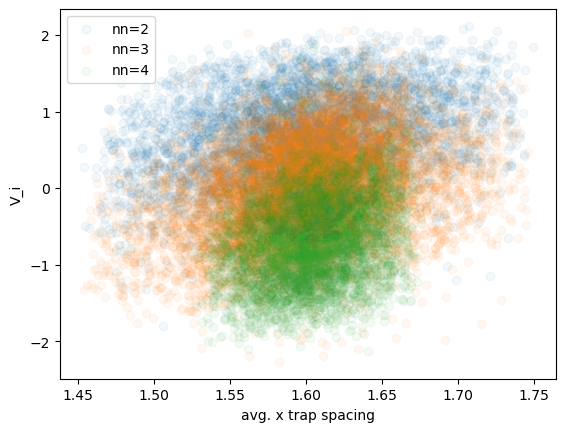

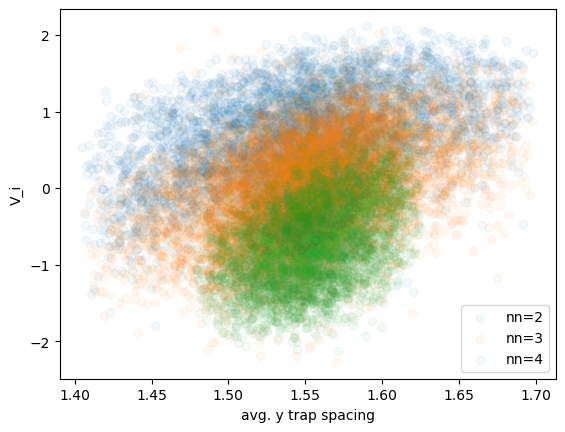

In [11]:
for i in [2, 3, 4]:
    plt.scatter(
        avgrx[:, nno == i], Vi[mask][:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}"
    )
plt.xlabel("avg. x trap spacing")
plt.ylabel("V_i")
plt.legend()

plt.figure()
for i in [2, 3, 4]:
    plt.scatter(
        avgry[:, nno == i], Vi[mask][:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}"
    )
plt.xlabel("avg. y trap spacing")
plt.ylabel("V_i")
plt.legend()

The dependence on trap spacing is not clear. But x, y follows the same law is sure.

### x y trap spacing

In [5]:
from typing import Iterable
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4

def nneighbors(index, width, height):
    if isinstance(index, Iterable):
        return np.array([nneighbors(i, width, height) for i in index])
    x = index % width
    y = index // height
    count = np.zeros(2, dtype=int)
    count[0] += 1 if x > 0 else 0  # left neighbor
    count[0] += 1 if x < width - 1 else 0  # right neighbor
    count[1] += 1 if y > 0 else 0  # top neighbor
    count[1] += 1 if y < height - 1 else 0  # bottom neighbor
    return count


nnxy = nneighbors(np.arange(16), width, height).T


def spacings(index, width, height):
    if isinstance(index, Iterable):
        return np.array([spacings(i, width, height) for i in index])
    x = index % width
    y = index // height
    xm1 = x - 1 if x > 0 else 0
    xp1 = x + 1 if x < width - 1 else width - 1
    ym1 = y - 1 if y > 0 else 0
    yp1 = y + 1 if y < height - 1 else height - 1
    return [y * width + xm1, y * width + xp1, ym1 * width + x, yp1 * width + x]


nidx = spacings(np.arange(16), width, height).T
xspacing = dat["rij"][mask][:, nidx[0], nidx[1]] / nnxy[0][None]
yspacing = dat["rij"][mask][:, nidx[2], nidx[3]] / nnxy[1][None]
spacing = [xspacing, yspacing]

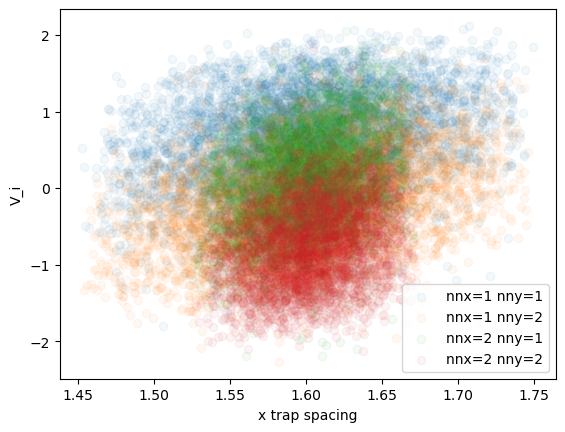

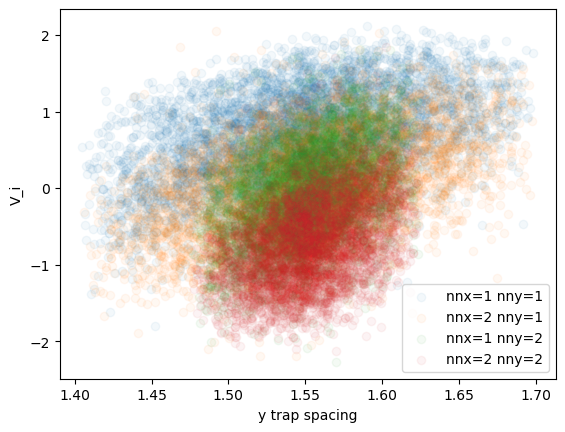

In [13]:
d = ["x", "y"]
k = 0



plt.figure()



for i in [1, 2]:
    for j in [1, 2]:

        plt.scatter(
            spacing[k][:, (nnxy[k] == i) * (nnxy[1 - k] == j)],
            Vi[mask][:, (nnxy[k] == i) * (nnxy[1 - k] == j)].flatten(),
            alpha=5e-2,
            label=f"nnx={i} nny={j}",
        )



plt.xlabel(f"{d[k]} trap spacing")
plt.ylabel("V_i")
plt.legend()

k = 1
plt.figure()
for i in [1, 2]:
    for j in [1, 2]:
        plt.scatter(
            spacing[k][:, (nnxy[k] == i) * (nnxy[1 - k] == j)],
            Vi[mask][:, (nnxy[k] == i) * (nnxy[1 - k] == j)].flatten(),
            alpha=5e-2,
            label=f"nnx={j} nny={i}",
        )
plt.xlabel(f"{d[k]} trap spacing")
plt.ylabel("V_i")
plt.legend()

It seems that nny's change doesn't change the model slope of x spacing, vice versa.

The model is additive, not multiplicative.

## Total trap depth

In [33]:
# zR = 4 * np.ones(2)
wxy = np.ones(2)
# zR0 = np.prod(zR) / np.linalg.norm(zR)
width = 4
height = 4
N = width * height
dim = 3


# def Vfun(x, y, z):
#     d0 = 1 + (z / zR0) ** 2 / 2
#     dxy = (x / wxy[0]) ** 2 / (1 + (z / zR[0]) ** 2)
#     dxy += (y / wxy[1]) ** 2 / (1 + (z / zR[1]) ** 2)
#     V = -1 / d0 * np.exp(-2 * dxy)
#     return V


def Vfun(x, y):
    dxy = x**2 + y**2
    V = -np.exp(-2 * dxy)
    return V


def tot_trap_depth(V0, trap_centers):
    # tc = np.zeros((N, dim))
    tc = np.zeros((N, 2))
    vij = np.ones((N, N))
    for i in range(N):
        # tc[i, :] = np.append(trap_centers[i], 0)
        tc[i, :] = trap_centers[i]
        for j in range(i):
            vij[i, j] = -Vfun(*(tc[i] - tc[j]))
            vij[j, i] = vij[i, j]  # Potential is symmetric in distance
    vtot = vij @ V0
    return vtot


vtot = np.array(
    list(map(tot_trap_depth, dat["V_offset"][mask], dat["trap_centers"][mask]))
)

Text(0, 0.5, 'V')

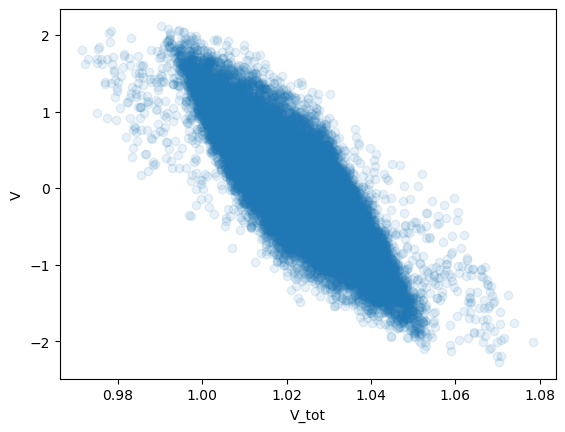

In [55]:
plt.scatter(vtot, Vi[mask], alpha=0.1)
plt.xlabel("V_tot")
plt.ylabel("V")

Onsite potential is highly, but not only linear to total trap depth.

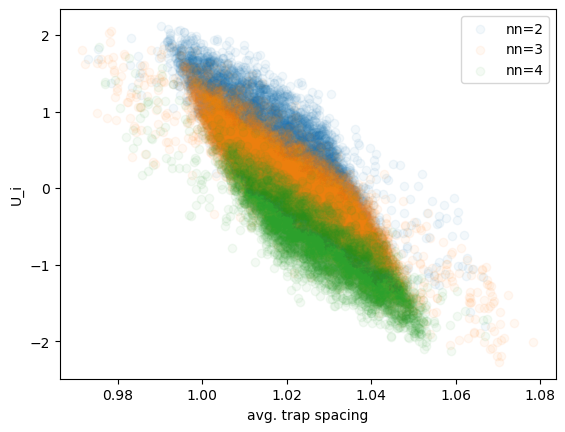

In [69]:
import matplotlib.pyplot as plt

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        vtot[:, nno == i], Vi[mask][:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}"
    )
plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

So the total trap depth accounts part of the effect by neighboring number, but not all.

In practice, the onsite potential is only the relative potential. So to capture this we can also plot it vs. relative total trap depth.

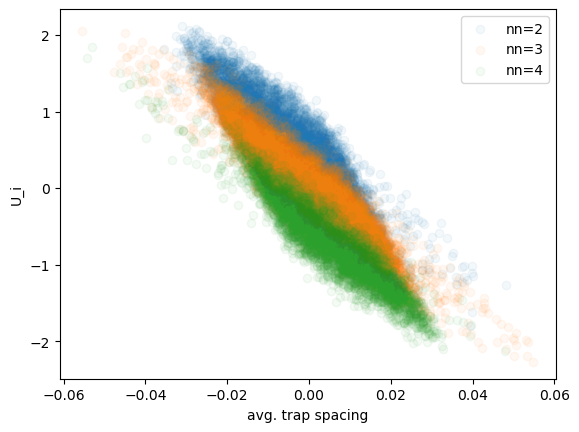

In [7]:
vtot_rel = vtot - np.mean(vtot, axis=1)[:, None]

import matplotlib.pyplot as plt

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        vtot_rel[:, nno == i], Vi[mask][:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}"
    )
plt.xlabel("rel. trap depth")
plt.ylabel("V_i")
plt.legend()

Slightly sharper dependence on relative total trap depth.

# Fit the data

## Model with total trap depth

We expect the scaling of $\mu$ to V_offset given by GS energy of the trap according to harmonic approximation: $W \sim \psi_0$

$$ \mu = \int W^\dagger [T+V] W d^3 x \sim E^{\text{GS}}_0 = -V_0 + \frac{3}{2}\hbar \omega = -V_0 + c \sqrt{V_0} $$

Since $c < 1$ first order we assume the dependence is linear. But it can be more accurate if we include the second term with fitting parameter $c$.

The trap spacing and trap neighbor number affect in fact the total trap depth, so that they determine $\mu$. THe Wannier function speradout is not that much important in this case due to the orthonormality of the Wannier functions.

In [58]:
Voff = dat["V_offset"][mask]
tc = dat["trap_centers"][mask]
X = np.array(list(map(tot_trap_depth, Voff, tc)))
Y = Vi[mask]

In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(torch.randn(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter
        self.c = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        return self.a * (-x + self.b * np.sqrt(x)) + self.c


# Convert data to torch tensors
X_torch = torch.tensor(X, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
bx = model.b.item()
c = model.c.item()

print(f"Model: Y = {a} * (-X + {bx} * sqrt(X)) + {c}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.3197
Epoch [2/1000], Loss: 0.3148
Epoch [3/1000], Loss: 0.3148
Epoch [4/1000], Loss: 0.3148
Final Loss: 0.3148
Model: Y = 90.36104583740234 * (-X + 0.9437686204910278 * sqrt(X)) + 6.161061763763428
R^2 Score: 0.6852437413863495


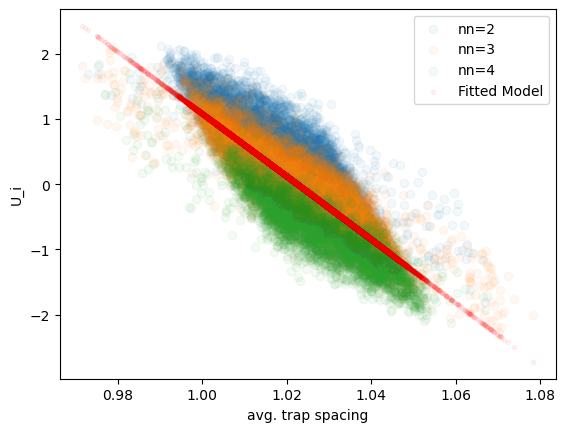

In [62]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(X[:, nno == i], Y[:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}")
# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=5e-2)

plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

### Total trap depth replaced by total relative trap depth?

We think of the same model, but with an assumption that the deviation from average is small, then

$$ \tilde{\mu}_i = \mu_i - \bar{\mu}_i \sim -V_{i} +c\sqrt{V_i} + \bar{V}_i - c\bar{\sqrt{V_i}} = -(V_{i} - \bar{V}_i ) +c \frac{V_{i} - \bar{V}_i }{\sqrt{V_i} + \bar{\sqrt{V_i}}} $$

From the assumption, then the second term on $V_{i} - \bar{V}_i$ is still linear, then the whole term can be approximated by a linear model on $V_{i} - \bar{V}_i$.

In [4]:
Voff = dat["V_offset"][mask]
tc = dat["trap_centers"][mask]
X = np.array(list(map(tot_trap_depth, Voff, tc)))
X = X - np.mean(X, axis=1)[:, None]
Y = Vi[mask]

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(torch.randn(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        return self.a * x + self.b


# Convert data to torch tensors
X_torch = torch.tensor(X, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
bx = model.b.item()

print(f"Model: Y = {a} * X + {bx}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.2603
Epoch [2/1000], Loss: 0.2597
Epoch [3/1000], Loss: 0.2597
Final Loss: 0.2597
Model: Y = -52.07217025756836 * X + 2.191007115470711e-05
R^2 Score: 0.740294896696948


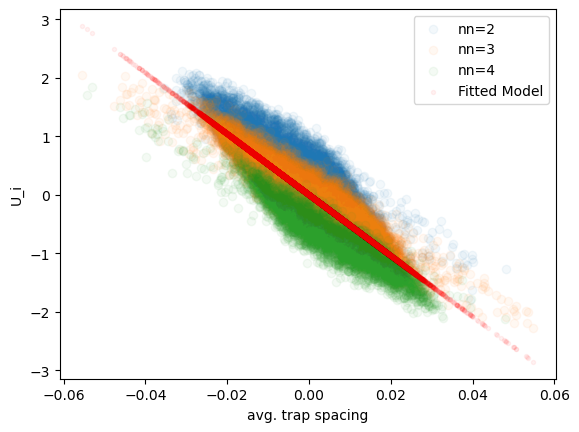

In [14]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(X[:, nno == i], Y[:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}")
# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=5e-2)

plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

This dependence is better than pure total trap depth.

## Model with trap depth and trap neighbor number

From the above we find that the trap depth and trap neighbor number affect not only the total trap depth. We need to include the effect of them sperately.

In [70]:
Voff = dat["V_offset"][mask]
tc = dat["trap_centers"][mask]
X = np.array(list(map(tot_trap_depth, Voff, tc)))
Y = Vi[mask]

In [6]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr

nno = nneighbor(width, height)
avgr = avg_trap_spacing(np.arange(width * height)).T

In [85]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(torch.randn((2,)))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter
        self.c = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        return (
            self.a[0] * (-x["vtot"] + self.a[1] * np.sqrt(x["vtot"]))
            + self.b * x["nn"][None]
            + self.c
        )


# Convert data to torch tensors
# X_torch = torch.tensor(np.log(X), dtype=torch.float32)
# Y_torch = torch.tensor(np.log(Y), dtype=torch.float32)
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
# X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nno, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a
bx = model.b.item()
c = model.c.item()

print(f"Model: Y = {a[0]} * (-X + {a[1]} * sqrt(X)) + {bx} * nno + {c}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.1756
Epoch [2/1000], Loss: 0.1313
Epoch [3/1000], Loss: 0.1313
Epoch [4/1000], Loss: 0.1313
Epoch [5/1000], Loss: 0.1313
Epoch [6/1000], Loss: 0.1313
Epoch [7/1000], Loss: 0.1313
Epoch [8/1000], Loss: 0.1313
Epoch [9/1000], Loss: 0.1313
Epoch [10/1000], Loss: 0.1313
Final Loss: 0.1313
Model: Y = 46.97828674316406 * (-X + 0.2548615336418152 * sqrt(X)) + -0.4904795289039612 * nno + 37.39924240112305
R^2 Score: 0.868665754920206


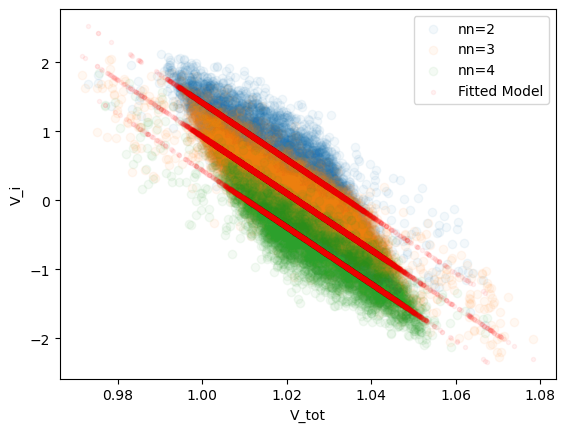

In [86]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(X[:, nno == i], Y[:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}")
# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=5e-2)

plt.xlabel("V_tot")
plt.ylabel("V_i")
plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

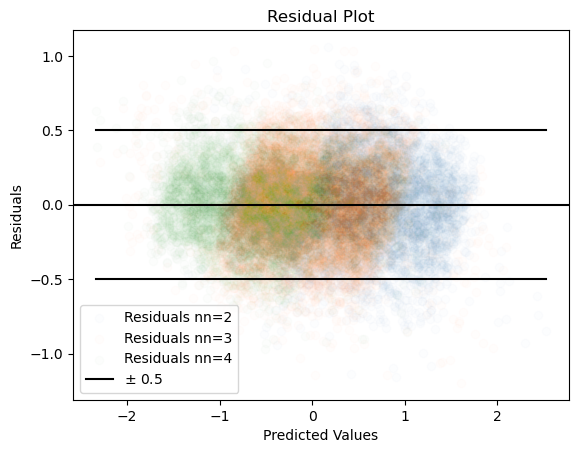

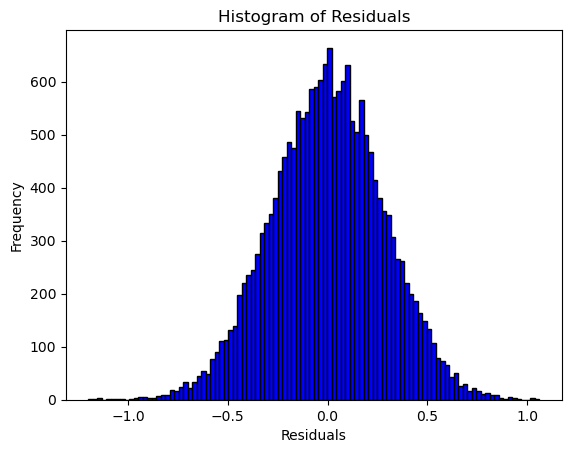

In [72]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=1e-2,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.5 * np.ones_like(x), color="k", label="$\pm$ 0.5")
plt.plot(x, -0.5 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np.flatten(), bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

### Relative trap depth

In [5]:
Voff = dat["V_offset"][mask]
tc = dat["trap_centers"][mask]
X = np.array(list(map(tot_trap_depth, Voff, tc)))
X = X - np.mean(X, axis=1)[:, None]
Y = Vi[mask]

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(torch.randn(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter
        self.c = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter

    def forward(self, x):
        return self.a * x["vtot"] + self.b * x["nn"][None] + self.c


# Convert data to torch tensors
# X_torch = torch.tensor(np.log(X), dtype=torch.float32)
# Y_torch = torch.tensor(np.log(Y), dtype=torch.float32)
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
# X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nno, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new
        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
bx = model.b.item()
c = model.c.item()

print(f"Model: Y = {a} X + {bx} * nno + {c}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.5311
Epoch [2/1000], Loss: 0.0911
Epoch [3/1000], Loss: 0.0911
Epoch [4/1000], Loss: 0.0911
Final Loss: 0.0911
Model: Y = -44.65434265136719 X + -0.47191470861434937 * nno + 1.4157687425613403
R^2 Score: 0.9088741856582232


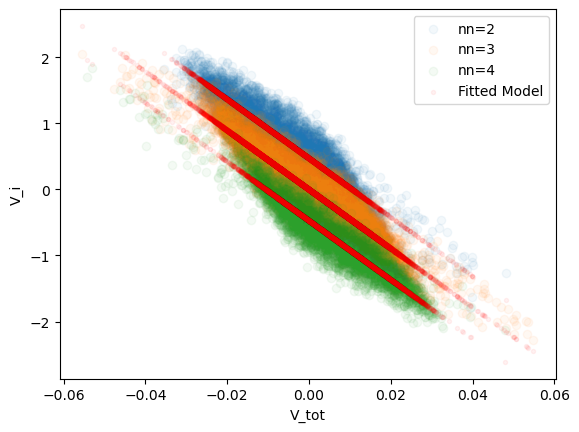

In [9]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(X[:, nno == i], Y[:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}")
# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=5e-2)

plt.xlabel("V_tot")
plt.ylabel("V_i")
plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

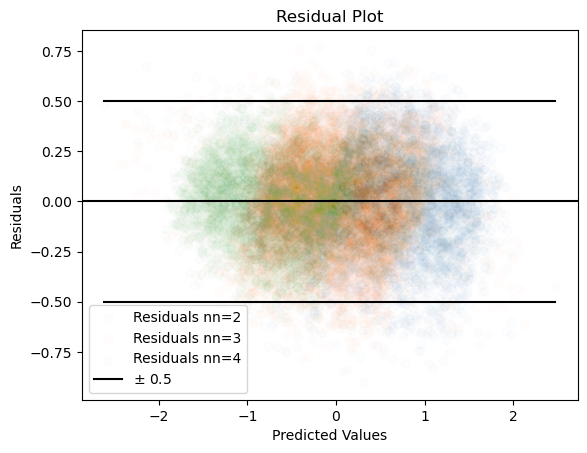

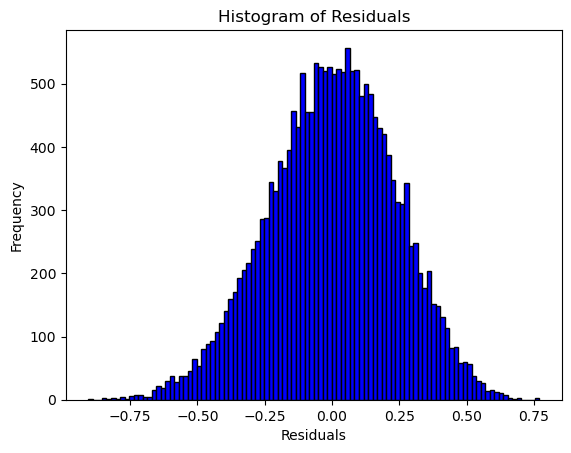

In [10]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=1e-2,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.5 * np.ones_like(x), color="k", label="$\pm$ 0.5")
plt.plot(x, -0.5 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np.flatten(), bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

### x y neighbor number

In [34]:
Voff = dat["V_offset"][mask]
tc = dat["trap_centers"][mask]
X = np.array(list(map(tot_trap_depth, Voff, tc)))
X = X - np.mean(X, axis=1)[:, None]
Y = Vi[mask]

In [35]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4

def nneighbors(index, width, height):
    if isinstance(index, Iterable):
        return np.array([nneighbors(i, width, height) for i in index])
    x = index % width
    y = index // height
    count = np.zeros(2, dtype=int)
    count[0] += 1 if x > 0 else 0  # left neighbor
    count[0] += 1 if x < width - 1 else 0  # right neighbor
    count[1] += 1 if y > 0 else 0  # top neighbor
    count[1] += 1 if y < height - 1 else 0  # bottom neighbor
    return count


nnxy = nneighbors(np.arange(16), width, height).T


def spacings(index, width, height):
    if isinstance(index, Iterable):
        return np.array([spacings(i, width, height) for i in index])
    x = index % width
    y = index // height
    xm1 = x - 1 if x > 0 else 0
    xp1 = x + 1 if x < width - 1 else width - 1
    ym1 = y - 1 if y > 0 else 0
    yp1 = y + 1 if y < height - 1 else height - 1
    return [y * width + xm1, y * width + xp1, ym1 * width + x, yp1 * width + x]


nidx = spacings(np.arange(16), width, height).T
xspacing = dat["rij"][mask][:, nidx[0], nidx[1]] / nnxy[0][None]
yspacing = dat["rij"][mask][:, nidx[2], nidx[3]] / nnxy[1][None]
spacing = [xspacing, yspacing]

In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(
            torch.randn((), dtype=torch.float64)
        )  # Initialize the 'a' parameter
        self.b = nn.Parameter(
            torch.randn((2,), dtype=torch.float64)
        )  # Initialize the 'b' parameter
        self.c = nn.Parameter(
            torch.randn((), dtype=torch.float64)
        )  # Initialize the 'b' parameter

    def forward(self, x):
        # ax = self.a[0] * x["nn"][0] + self.a[1]
        # ay = self.a[2] * x["nn"][1] + self.a[3]
        # return ax[None] * ay[None] * x["vtot"] + self.b[None] @ x["nn"] + self.c
        return self.a * x["vtot"] + self.b[None] @ x["nn"] + self.c


# Convert data to torch tensors
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
# X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nnxy, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new
        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
bx = model.b
c = model.c.item()

print(f"Model: Y = {a} * X + [{bx[0]} {bx[1]}] * nn + {c}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.3612
Epoch [2/1000], Loss: 0.0891
Epoch [3/1000], Loss: 0.0891
Epoch [4/1000], Loss: 0.0891
Final Loss: 0.0891
Model: Y = -44.45997195568899 * X + [-0.4230579750771936 -0.5226715006395595] * nn + 1.4187354334294495
R^2 Score: 0.9109091339752384


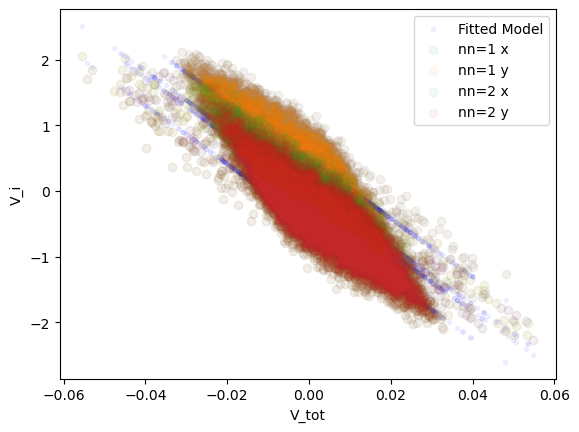

In [54]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the model's predictions
plt.scatter(X, predicted, color="b", label="Fitted Model", marker=".", alpha=5e-2)

# Plotting the original data
for i in [1, 2]:
    for j in range(2):
        plt.scatter(
            X[:, nnxy[j] == i],
            Y[:, nnxy[j] == i].flatten(),
            alpha=5e-2,
            label=f"nn={i} {['x', 'y'][j]}",
        )

plt.xlabel("V_tot")
plt.ylabel("V_i")
plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

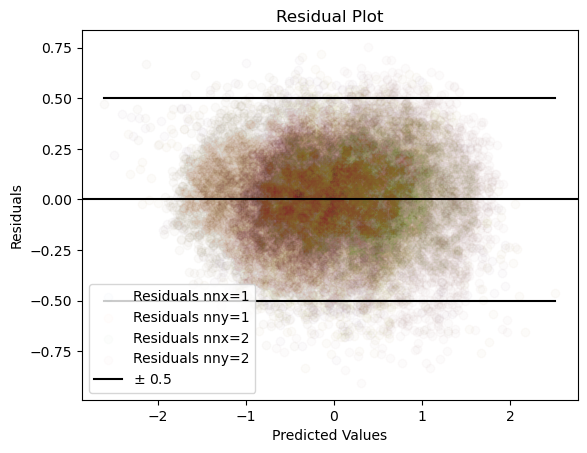

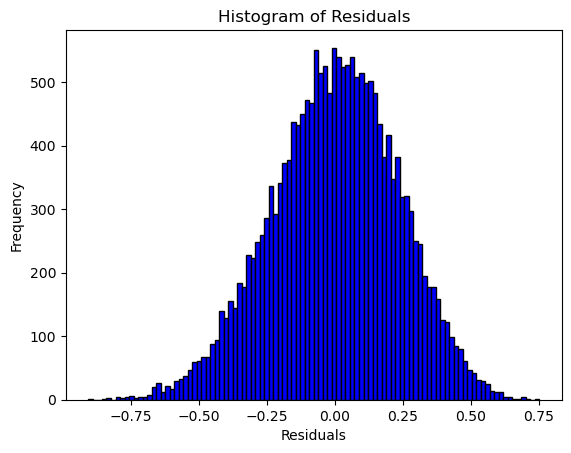

In [56]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [1, 2]:
    for j in range(2):
        plt.scatter(
            predictions_np[:, nnxy[j] == i].flatten(),
            residuals_np[:, nnxy[j] == i].flatten(),
            # color="blue",
            alpha=1e-2,
            label=f"Residuals nn{['x', 'y'][j]}={i}",
        )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.5 * np.ones_like(x), color="k", label="$\pm$ 0.5")
plt.plot(x, -0.5 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np.flatten(), bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

## Model with above and trap spacing

In [73]:
Voff = dat["V_offset"][mask]
tc = dat["trap_centers"][mask]
X = np.array(list(map(tot_trap_depth, Voff, tc)))
Y = Vi[mask]

In [74]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr

nno = nneighbor(width, height)
avgr = avg_trap_spacing(np.arange(width * height)).T

In [89]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.a = nn.Parameter(torch.randn((2,)))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn((2,)))  # Initialize the 'b' parameter
        self.c = nn.Parameter(torch.randn((2,)))  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        a = self.a[0] * (-x["vtot"] + self.a[1] * np.sqrt(x["vtot"]))
        b = self.b[0] * x["nn"][None] + self.b[1]
        c = self.c[0] * x["nn"][None] + self.c[1]
        return a + b * x["avgr"] + c


# Convert data to torch tensors
# X_torch = torch.tensor(np.log(X), dtype=torch.float32)
# Y_torch = torch.tensor(np.log(Y), dtype=torch.float32)
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nno, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a
bx = model.b
c = model.c

print(
    f"Exponential model: Y = {a[0]} * (- X + {a[1]} * sqrt(X)) + ({bx[0]} * nno + {bx[1]}) * avgr + ({c[0]} * nno + {c[1]})"
)
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.2242
Epoch [2/1000], Loss: 0.0547
Epoch [3/1000], Loss: 0.0537
Epoch [4/1000], Loss: 0.0537
Epoch [5/1000], Loss: 0.0537
Final Loss: 0.0537
Exponential model: Y = 1.2831041812896729 * (- X + -56.40480041503906 * sqrt(X)) + (1.5769944190979004 * nno + 2.937164306640625) * avgr + (-3.023024082183838 * nno + 71.4711685180664)
R^2 Score: 0.9462924969917974


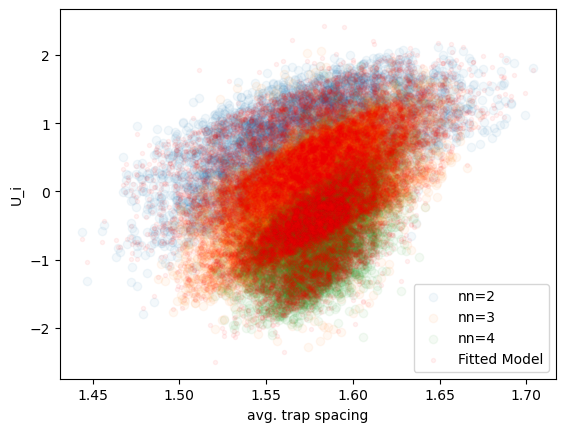

In [76]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the model's predictions
plt.scatter(avgr, predicted, color="red", label="Fitted Model", marker=".", alpha=5e-2)

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(avgr[:, nno == i], Y[:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}")

plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

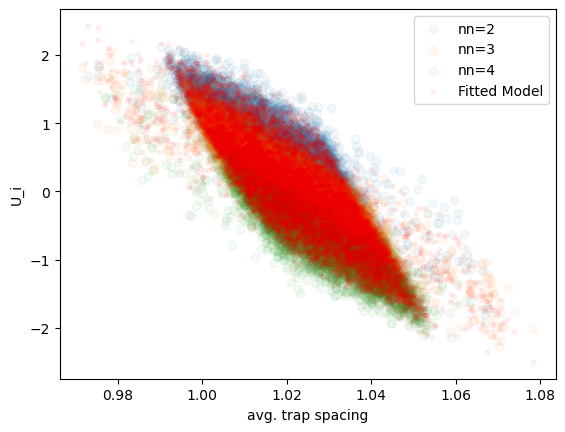

In [77]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=5e-2)

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(X[:, nno == i], Y[:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}")

plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

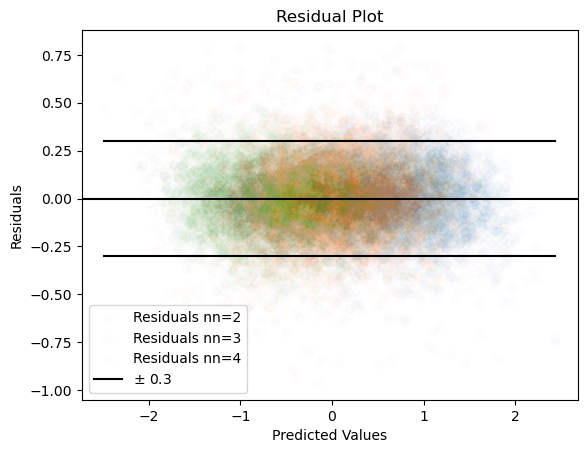

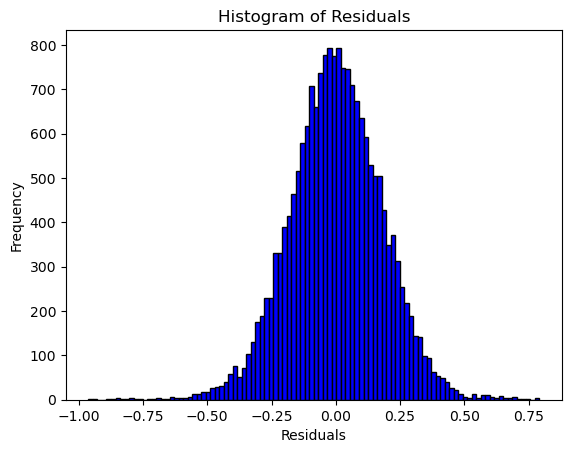

In [90]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=1e-2,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.3 * np.ones_like(x), color="k", label="$\pm$ 0.3")
plt.plot(x, -0.3 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np.flatten(), bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

### Relative trap depth

In [11]:
Voff = dat["V_offset"][mask]
tc = dat["trap_centers"][mask]
X = np.array(list(map(tot_trap_depth, Voff, tc)))
X = X - np.mean(X, axis=1)[:, None]
Y = Vi[mask]

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.a = nn.Parameter(torch.randn(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn((2,)))  # Initialize the 'b' parameter
        self.c = nn.Parameter(torch.randn((2,)))  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        a = self.a * x["vtot"]
        b = self.b[0] * x["nn"][None] + self.b[1]
        c = self.c[0] * x["nn"][None] + self.c[1]
        return a + b * x["avgr"] + c


# Convert data to torch tensors
# X_torch = torch.tensor(np.log(X), dtype=torch.float32)
# Y_torch = torch.tensor(np.log(Y), dtype=torch.float32)
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nno, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
bx = model.b
c = model.c

print(
    f"Model: Y = {a} * X + ({bx[0]} * nno + {bx[1]}) * avgr + {c[0]} * nno + {c[1]}"
)
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.5809
Epoch [2/1000], Loss: 0.0137
Epoch [3/1000], Loss: 0.0133
Epoch [4/1000], Loss: 0.0133
Final Loss: 0.0133
Model: Y = -40.67880630493164 * X + (1.5553295612335205 * nno + 2.9900264739990234) * avgr + -2.9700324535369873 * nno + -3.1613504886627197
R^2 Score: 0.9867450046129073


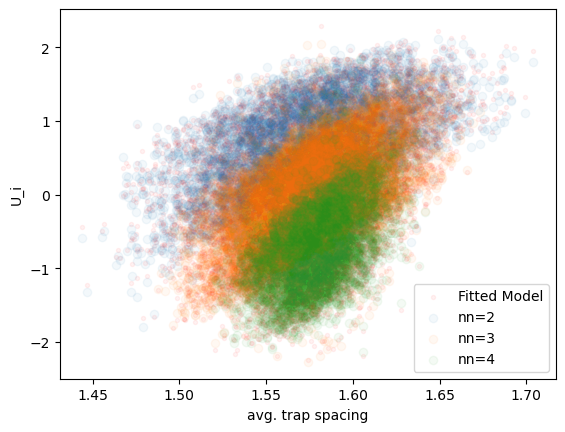

In [13]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the model's predictions
plt.scatter(avgr, predicted, color="red", label="Fitted Model", marker=".", alpha=5e-2)

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(avgr[:, nno == i], Y[:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}")

plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

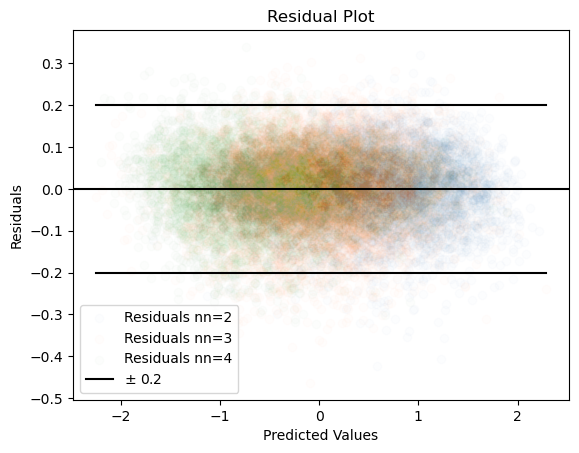

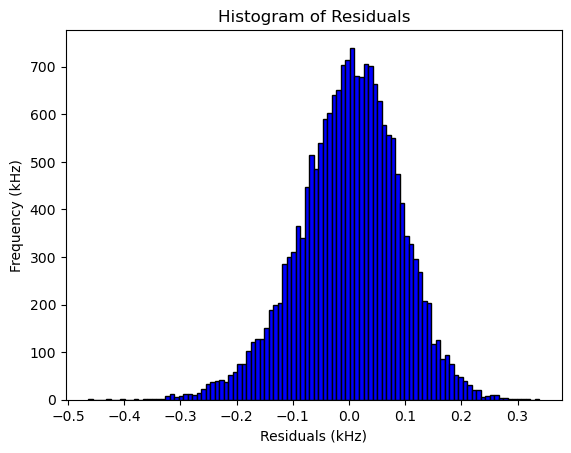

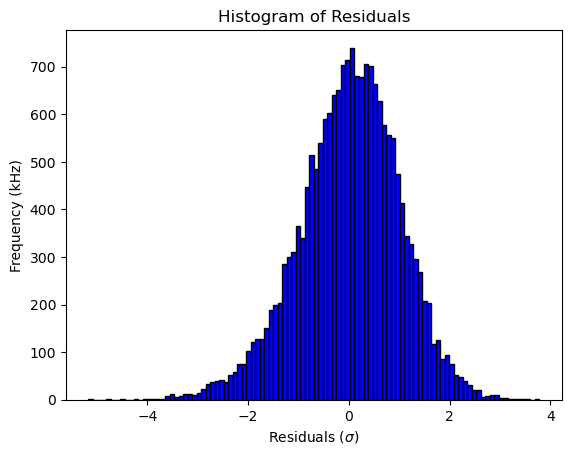

In [24]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()
sigma = np.std(residuals_np)

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=1e-2,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.2 * np.ones_like(x), color="k", label="$\pm$ 0.2")
plt.plot(x, -0.2 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np.flatten(), bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals (kHz)")
plt.ylabel("Frequency (kHz)")
plt.title("Histogram of Residuals")

# Optional: Histogram of Residuals ratio to sigma
plt.figure()
plt.hist(residuals_np.flatten() / sigma, bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals ($\sigma$)")
plt.ylabel("Frequency (kHz)")
plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")

THe data range is roughly from -2 to 2 and the residual is around +-0.2. So R2 is this squared  ~0.99.

### x y separate spacing

In [57]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4

def nneighbors(index, width, height):
    if isinstance(index, Iterable):
        return np.array([nneighbors(i, width, height) for i in index])
    x = index % width
    y = index // height
    count = np.zeros(2, dtype=int)
    count[0] += 1 if x > 0 else 0  # left neighbor
    count[0] += 1 if x < width - 1 else 0  # right neighbor
    count[1] += 1 if y > 0 else 0  # top neighbor
    count[1] += 1 if y < height - 1 else 0  # bottom neighbor
    return count


nnxy = nneighbors(np.arange(16), width, height).T


def spacings(index, width, height):
    if isinstance(index, Iterable):
        return np.array([spacings(i, width, height) for i in index])
    x = index % width
    y = index // height
    xm1 = x - 1 if x > 0 else 0
    xp1 = x + 1 if x < width - 1 else width - 1
    ym1 = y - 1 if y > 0 else 0
    yp1 = y + 1 if y < height - 1 else height - 1
    return [y * width + xm1, y * width + xp1, ym1 * width + x, yp1 * width + x]


nidx = spacings(np.arange(16), width, height).T
xspacing = dat["rij"][mask][:, nidx[0], nidx[1]] / nnxy[0][None]
yspacing = dat["rij"][mask][:, nidx[2], nidx[3]] / nnxy[1][None]
spacing = [xspacing, yspacing]

In [58]:
Voff = dat["V_offset"][mask]
tc = dat["trap_centers"][mask]
X = np.array(list(map(tot_trap_depth, Voff, tc)))
X = X - np.mean(X, axis=1)[:, None]
Y = Vi[mask]

In [84]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(
            torch.randn((), dtype=torch.float64)
        )  # Initialize the 'a' parameter
        self.b = nn.Parameter(
            torch.randn((4,), dtype=torch.float64)
        )  # Initialize the 'b' parameter
        self.c = nn.Parameter(
            torch.randn((4,), dtype=torch.float64)
        )  # Initialize the 'b' parameter

    def forward(self, x):
        # ax = self.a[0] * x["nn"][0] + self.a[1]
        # ay = self.a[2] * x["nn"][1] + self.a[3]
        # return ax[None] * ay[None] * x["vtot"] + self.b[None] @ x["nn"] + self.c
        bx = self.b[0] * x["nn"][0][None] + self.b[1]
        xterm = bx * x["spacing"][0] + self.c[0] * x["nn"][0][None] + self.c[1]
        by = self.b[2] * x["nn"][1][None] + self.b[3]
        yterm = by * x["spacing"][1] + self.c[2] * x["nn"][1][None] + self.c[3]
        return self.a * x["vtot"] + xterm + yterm


# Convert data to torch tensors
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
X_torch["spacing"] = torch.tensor(spacing, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nnxy, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new
        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
b = model.b
c = model.c

print(
    f"Model: Y = {a} * X + (({b[0]} * nnx + {b[1]}) * spacingx + {c[0]} * nnx + {c[1]}) + (({b[2]} * nny + {b[3]}) * spacingy + {c[2]} * nny + {c[3]})"
)
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.4258
Epoch [2/1000], Loss: 0.0115
Epoch [3/1000], Loss: 0.0115
Epoch [4/1000], Loss: 0.0115
Final Loss: 0.0115
Model: Y = -40.567793178177254 * X + ((1.673680089755034 * nnx + 0.8907089919419883) * spacingx + -3.144102152543089 * nnx + -1.370410125419597) + ((1.77019550764624 * nny + 1.5740520265546007) * spacingy + -3.3122881079457267 * nny + -0.9517428156830422)
R^2 Score: 0.9885138197662255


Text(0.5, 1.0, 'Histogram of Residuals')

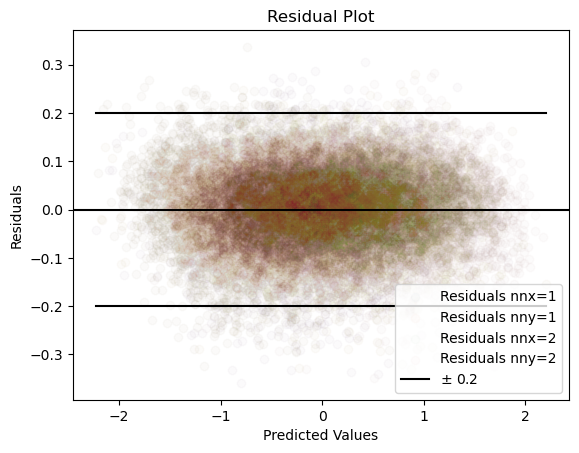

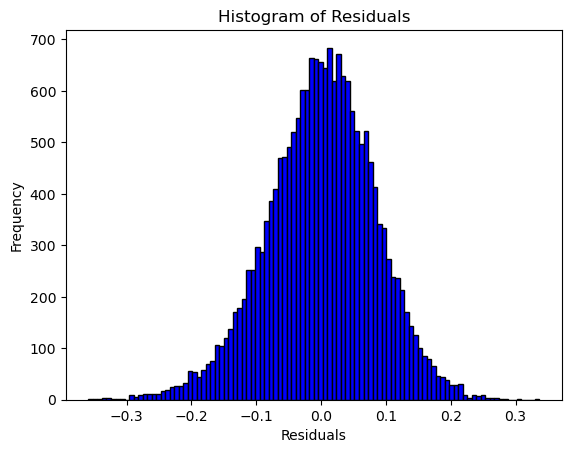

In [82]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [1, 2]:
    for j in range(2):
        plt.scatter(
            predictions_np[:, nnxy[j] == i].flatten(),
            residuals_np[:, nnxy[j] == i].flatten(),
            # color="blue",
            alpha=1e-2,
            label=f"Residuals nn{['x', 'y'][j]}={i}",
        )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.2 * np.ones_like(x), color="k", label="$\pm$ 0.2")
plt.plot(x, -0.2 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np.flatten(), bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

#### TEST: Vtot + f(spacing) or Vtot * f(spacing)?

In [87]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(
            torch.randn((), dtype=torch.float64)
        )  # Initialize the 'a' parameter
        self.b = nn.Parameter(
            torch.randn((4,), dtype=torch.float64)
        )  # Initialize the 'b' parameter
        self.c = nn.Parameter(
            torch.randn((4,), dtype=torch.float64)
        )  # Initialize the 'b' parameter

    def forward(self, x):
        # ax = self.a[0] * x["nn"][0] + self.a[1]
        # ay = self.a[2] * x["nn"][1] + self.a[3]
        # return ax[None] * ay[None] * x["vtot"] + self.b[None] @ x["nn"] + self.c
        bx = self.b[0] * x["nn"][0][None] + self.b[1]
        xterm = bx * x["spacing"][0] + self.c[0] * x["nn"][0][None] + self.c[1]
        by = self.b[2] * x["nn"][1][None] + self.b[3]
        yterm = by * x["spacing"][1] + self.c[2] * x["nn"][1][None] + self.c[3]
        return x["vtot"] * (xterm + yterm) + self.a


# Convert data to torch tensors
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
X_torch["spacing"] = torch.tensor(spacing, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nnxy, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new
        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
b = model.b
c = model.c

print(
    f"Model: Y = ((({b[0]} * nnx + {b[1]}) * spacingx + {c[0]} * nnx + {c[1]}) + (({b[2]} * nny + {b[3]}) * spacingy + {c[2]} * nny + {c[3]})) * X + {a}"
)
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.2727
Epoch [2/1000], Loss: 0.2582
Epoch [3/1000], Loss: 0.2514
Epoch [4/1000], Loss: 0.2514
Epoch [5/1000], Loss: 0.2514
Final Loss: 0.2514
Model: Y = (((25.008576662413258 * nnx + -51.578945170138994) * spacingx + -38.894916450969646 * nnx + 294.2714547566972) + ((265.2559381323055 * nny + -363.08582737038523) * spacingy + -410.50649974154516 * nny + 296.19654214680384)) * X + -0.0043229888488267336
R^2 Score: 0.7486375804767178


In [88]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(
            torch.randn((), dtype=torch.float64)
        )  # Initialize the 'a' parameter
        self.b = nn.Parameter(
            torch.randn((4,), dtype=torch.float64)
        )  # Initialize the 'b' parameter
        self.c = nn.Parameter(
            torch.randn((4,), dtype=torch.float64)
        )  # Initialize the 'b' parameter

    def forward(self, x):
        # ax = self.a[0] * x["nn"][0] + self.a[1]
        # ay = self.a[2] * x["nn"][1] + self.a[3]
        # return ax[None] * ay[None] * x["vtot"] + self.b[None] @ x["nn"] + self.c
        bx = self.b[0] * x["nn"][0][None] + self.b[1]
        xterm = bx * x["spacing"][0] + self.c[0] * x["nn"][0][None] + self.c[1]
        by = self.b[2] * x["nn"][1][None] + self.b[3]
        yterm = by * x["spacing"][1] + self.c[2] * x["nn"][1][None] + self.c[3]
        return x["vtot"] * (xterm * yterm) + self.a


# Convert data to torch tensors
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
X_torch["spacing"] = torch.tensor(spacing, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nnxy, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new
        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
b = model.b
c = model.c

print(
    f"Model: Y = ((({b[0]} * nnx + {b[1]}) * spacingx + {c[0]} * nnx + {c[1]}) * (({b[2]} * nny + {b[3]}) * spacingy + {c[2]} * nny + {c[3]})) * X + {a}"
)
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.2580
Epoch [2/1000], Loss: 0.2519
Epoch [3/1000], Loss: 0.2508
Epoch [4/1000], Loss: 0.2508
Epoch [5/1000], Loss: 0.2508
Final Loss: 0.2508
Model: Y = (((-15.292748026070743 * nnx + 22.772851351263647) * spacingx + 24.269629988057552 * nnx + -27.833007411196117) * ((30.779675942300074 * nny + -42.778382090574986) * spacingy + -47.590622770071526 * nny + 59.834457508062194)) * X + -0.005304894641865975
R^2 Score: 0.7492038527196837


The sum of factor terms is better than the product of factor terms.